## Import Libraries :

In [97]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## Load Dataset Using Pandas :

In [98]:
df = pd.read_csv("customer_churn_data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes


In [99]:
# Shape of Data
df.shape


(5880, 21)

In [100]:
#Find the columns in DataSet
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

## Data Set Information :

In [101]:
#Data type check
#Null value check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5880 non-null   str    
 1   gender            5880 non-null   str    
 2   SeniorCitizen     5880 non-null   int64  
 3   Partner           5880 non-null   str    
 4   Dependents        5880 non-null   str    
 5   tenure            5880 non-null   int64  
 6   PhoneService      5880 non-null   str    
 7   MultipleLines     5880 non-null   str    
 8   InternetService   5880 non-null   str    
 9   OnlineSecurity    5880 non-null   str    
 10  OnlineBackup      5880 non-null   str    
 11  DeviceProtection  5880 non-null   str    
 12  TechSupport       5880 non-null   str    
 13  StreamingTV       5880 non-null   str    
 14  StreamingMovies   5880 non-null   str    
 15  Contract          5880 non-null   str    
 16  PaperlessBilling  5880 non-null   str    
 17  Paymen

In [102]:
#Statistics check
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5880.000000,5880.000000,5880.000000,5880.000000
mean,0.500680,36.549150,70.157779,2566.813165
std,0.500042,20.909674,28.804615,1910.017743
min,0.000000,1.000000,20.000000,20.030000
25%,0.000000,18.000000,45.717500,1020.217500
50%,1.000000,37.000000,70.155000,2136.445000
75%,1.000000,55.000000,95.457500,3767.665000
max,1.000000,72.000000,119.990000,8589.600000


## Numpy Statistics :

In [103]:
#Montly charges Mean
np.mean(df["MonthlyCharges"])

np.float64(70.15777891156462)

In [104]:
#Median
np.median(df["MonthlyCharges"])

np.float64(70.155)

In [105]:
#Maximum
np.max(df["MonthlyCharges"])

np.float64(119.99)

In [106]:
#Minimum
np.min(df["MonthlyCharges"])

np.float64(20.0)

In [107]:
# Standard Deviation
np.std(df["MonthlyCharges"])

np.float64(28.80216534103074)

## Missing Values :

In [108]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Duplicate Records :

In [109]:
df.duplicated().sum()

np.int64(0)

In [110]:
# if Duplicate occur Remove Duplicates 
df.drop_duplicates(inplace=True)

## Check target Variable :

In [111]:
df["Churn"].value_counts()

Churn
No     2982
Yes    2898
Name: count, dtype: int64

In [112]:
#Percentage
df["Churn"].value_counts(normalize=True)*100

Churn
No     50.714286
Yes    49.285714
Name: proportion, dtype: float64

## EDA Using Seaborn : 

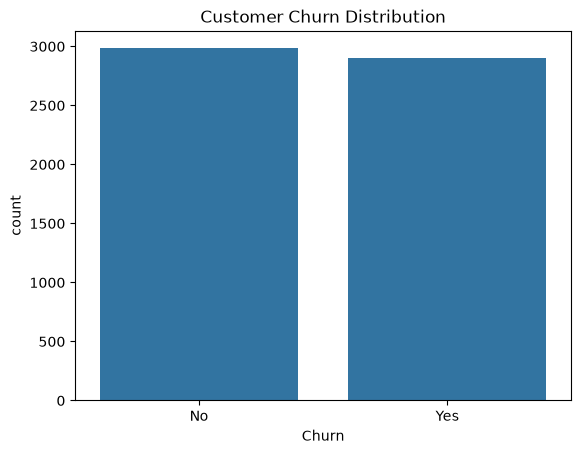

In [113]:
# Churn Distribution
sns.countplot(x="Churn",data=df)

plt.title("Customer Churn Distribution" )
plt.show()

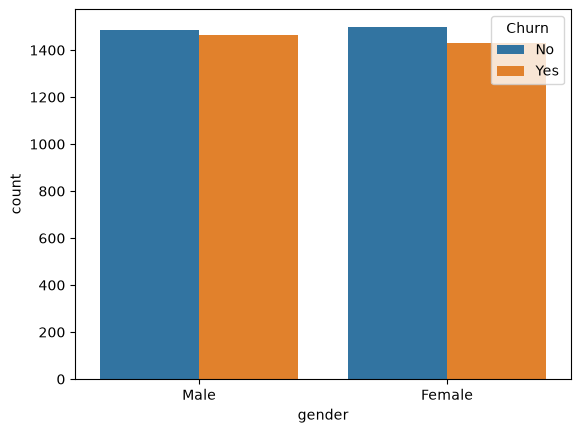

In [114]:
# Gender VS churn :
sns.countplot(
    x="gender",
    hue="Churn",
    data=df
)

plt.show()

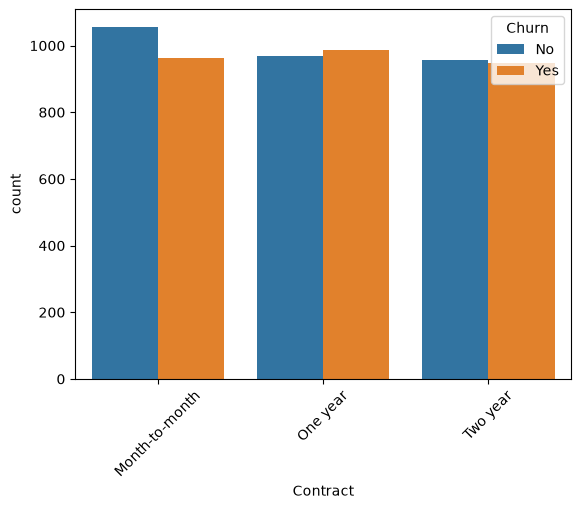

In [115]:
#Contract VS Churn
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)
plt.show()

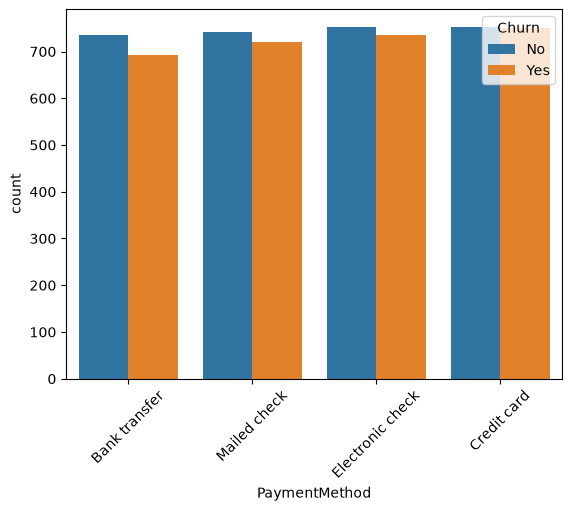

In [116]:
#Payment Method vs Churn
sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)
plt.show()

## Histograms :

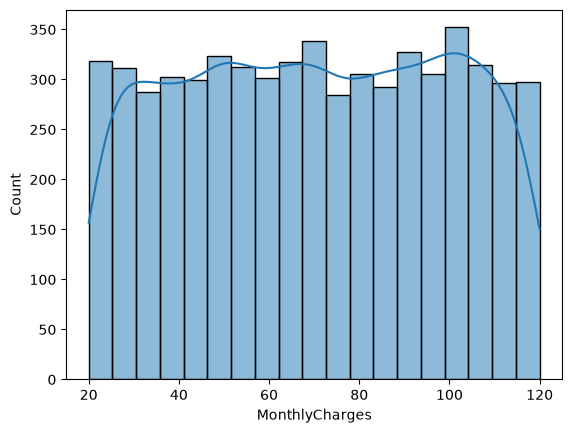

In [117]:
#Monthly Charges
sns.histplot(
    df["MonthlyCharges"],
    kde=True
)

plt.show()

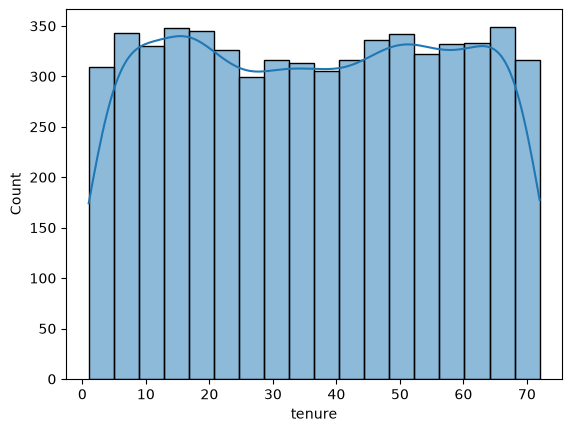

In [118]:
#Tensure
sns.histplot(
    df["tenure"],
    kde=True
)

plt.show()

## Boxplots :

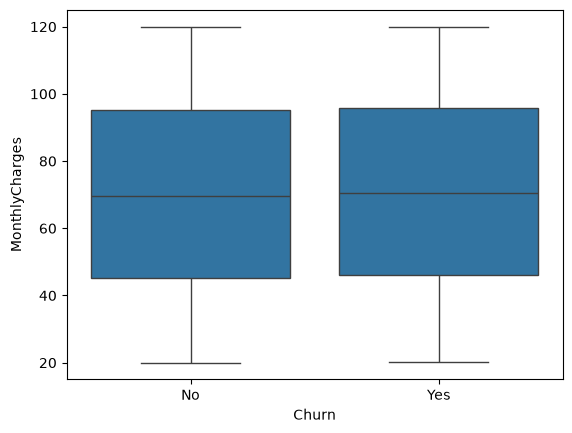

In [119]:
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.show()

 ## Correlation using Heatmap :

In [120]:
#First encode Target
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})
df['Churn'].head()

0    0
1    1
2    1
3    0
4    1
Name: Churn, dtype: int64

In [121]:
#Select numerical columns
num_df = df.select_dtypes(
    include=np.number
)

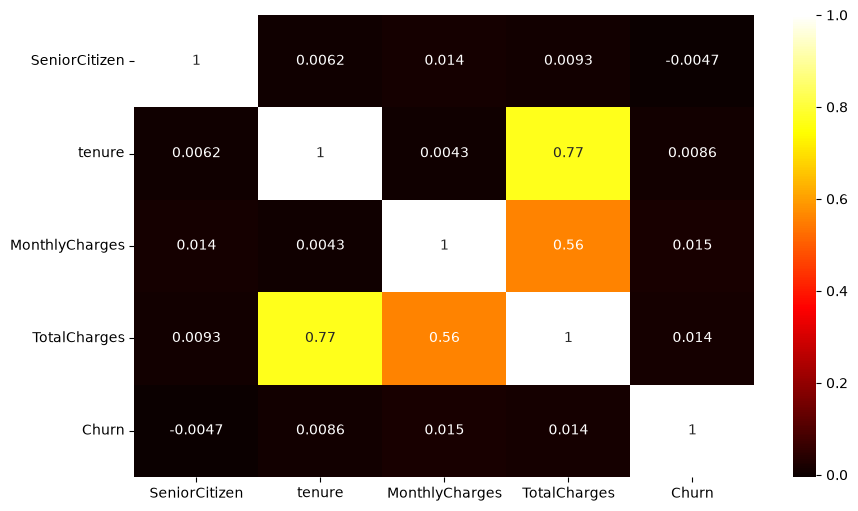

In [123]:
#heat map
plt.figure(figsize=(10,6))

sns.heatmap(
    num_df.corr(),
    annot=True,
    cmap="hot"
)

plt.show()

## Feature Enginneering

In [ ]:
df.drop(
    "customerID",
    axis=1,
    inplace=True
)

## Encoding

In [ ]:
df = pd.get_dummies(
    df,
    drop_first=True
)

#check shape
df.shape

(5880, 31)

## Features and Target

In [ ]:
X = df.drop(
    "Churn",
    axis=1
)

y = df["Churn"]

## Train test split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Logistic regression:

In [ ]:
lr = LogisticRegression(
    max_iter=5000
)

lr.fit(
    X_train,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [ ]:
#Predition
lr_pred = lr.predict(X_test)

In [ ]:
#Accuracy
accuracy_score(
    y_test,
    lr_pred
)

0.47874149659863946

## Decision Tree :

In [ ]:
dt = DecisionTreeClassifier()

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(X_test)

In [ ]:
#Accuracy
accuracy_score(
    y_test,
    dt_pred
)

0.5068027210884354

## Random Forest:

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

In [ ]:
#Accuracy
accuracy_score(
    y_test,
    rf_pred
)

0.49744897959183676

## Confusion Matrix:

In [ ]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

print(cm)

[[322 262]
 [329 263]]


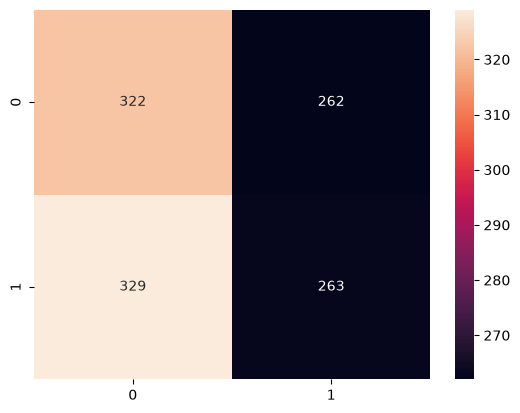

In [ ]:
#Visualize
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.show()

## Classification Report:

In [ ]:
#accuracy ,precision , recall ,F1Score
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.49      0.55      0.52       584
           1       0.50      0.44      0.47       592

    accuracy                           0.50      1176
   macro avg       0.50      0.50      0.50      1176
weighted avg       0.50      0.50      0.50      1176



# Feature Importance:

In [ ]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
2,MonthlyCharges,0.180899
3,TotalCharges,0.179804
1,tenure,0.159932
4,gender_Male,0.033282
0,SeniorCitizen,0.033210
5,Partner_Yes,0.032497
26,PaperlessBilling_Yes,0.031921
6,Dependents_Yes,0.029952
25,Contract_Two year,0.026942
24,Contract_One year,0.024853


## Save Model in Pickel format:

In [ ]:
import joblib

joblib.dump(
    rf,
    "customer_churn_data.pkl"
)

['customer_churn_data.pkl']